In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.1)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

In [3]:
@np.vectorize
def zprimeFF(s, M_Zp, G_Zp=1.0, 
             Qq=2./3., gq = 8.433350e-03, gt = 3.543073e-01):
    x = s / M_Zp**2
    e2 = 4*np.pi/127
    numerator = x**2*(1 + (4/3)*(Qq*e2/(gq*gt))*(1-1/x))
    denominator = (1 - x)**2 + G_Zp**2/M_Zp**2
    ff = numerator / denominator
    return ff

@np.vectorize
def vlfFF(s,M):
    x = s / M**2
    Delta = np.lib.scimath.sqrt(x**2 - 4 * x)
    L = np.lib.scimath.log(1 + (Delta / 2.0) - (x / 2.0))
    ff = (L/x)*(Delta-L) + 1

    return ff

@np.vectorize
def scalarFF(s,M):
    x = s / M**2
    Delta = np.lib.scimath.sqrt(x**2 - 4 * x)
    L = np.lib.scimath.log(1 + (Delta / 2.0) - (x / 2.0))
    ff = (L/x)*(Delta+L) + 3

    return ff



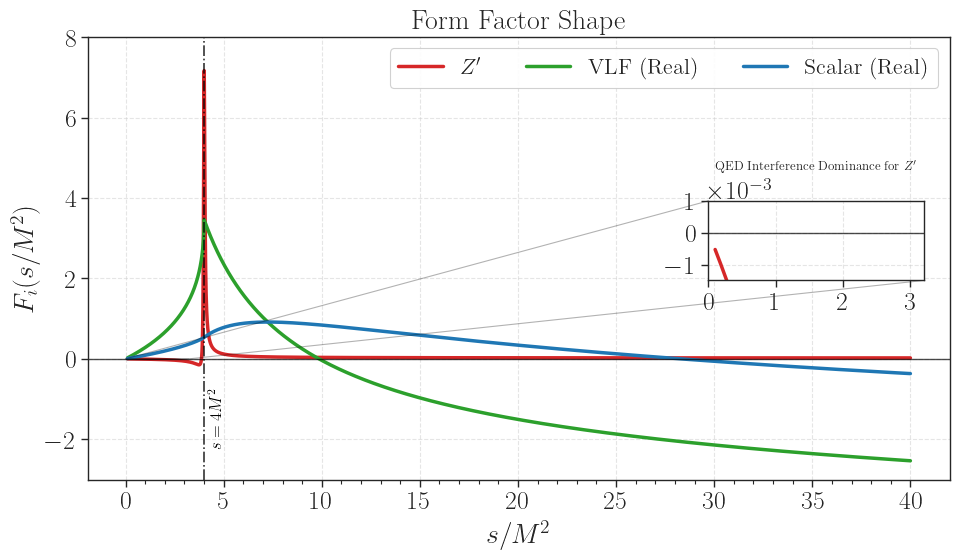

In [9]:
# Color palette
colors = plt.cm.tab10.colors

# --- Parameters ---
M_T = m = 1000.0
s_values = np.linspace(0.1 * m**2, 40 * m**2, 10000)

# --- Vectorized Complex Kinematics (Dimensionless x = s/M^2) ---
x = s_values / m**2

# Dimensionless Form Factors
F_scalar = scalarFF(s_values, m)
F_vlf = vlfFF(s_values, m)


# --- Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

# Z' Resonance
M_Zp = 2.0 * m
F_zp = zprimeFF(s_values, M_Zp, G_Zp=M_Zp/100.0)
y_zp = 7e-4 * F_zp
ax.plot(x, y_zp, color=colors[3], linewidth=2.5, alpha=1, label=r'$Z^\prime$')

# VLF Curves (Real & Imaginary)
ax.plot(x, F_vlf.real, label='VLF (Real)', color=colors[2], linestyle='-', linewidth=2.5)

# Scalar Curves (Real & Imaginary)
ax.plot(x, F_scalar.real, label='Scalar (Real)', color=colors[0], linestyle='-', linewidth=2.5)

# Formatting
ax.axvline(4.0, color='black', linestyle='-.', alpha=0.8)
ax.axhline(0.0, color='black', linewidth=1, alpha=0.7)

# Vertical annotation in the negative y-region
ax.text(4.3, -1.5, r'$s = 4M^2$', fontsize=12, color='black', 
        rotation=90, verticalalignment='center')

ax.set_title(r'Form Factor Shape') 
ax.set_xlabel(r'$s/M^2$')            
ax.set_ylabel(r'$F_i(s/M^2)$')              

ax.set_ylim([-3, 8.0])
ax.legend(loc='upper right', framealpha=0.9, ncol=3, fontsize=16) 
ax.tick_params(axis='both', which='major') 

ax.grid(True, alpha=0.5, linestyle='--')

minor_tick_locations = np.arange(0.0, 41.0, 1.0) 
ax.xaxis.set_minor_locator(FixedLocator(minor_tick_locations))

# ==========================================
# INSET ZOOM (Highlighting Z' negative tail)
# ==========================================
axins = ax.inset_axes([0.72, 0.45, 0.25, 0.18]) 

axins.plot(x, y_zp, color=colors[3], linewidth=2.5)
axins.plot(x, F_vlf.real, color=colors[2], linestyle='-', linewidth=2.5)
axins.plot(x, F_scalar.real, color=colors[0], linestyle='-', linewidth=2.5)
axins.axhline(0.0, color='black', linewidth=1, alpha=0.7)

axins.set_xlim(0, 3.2)
axins.set_ylim(-0.0015, 0.001) 

axins.set_xticks([0, 1, 2, 3])
axins.set_yticks([-0.001, 0.0, 0.001])
axins.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

axins.grid(True, alpha=0.5, linestyle='--')
axins.set_title(r"QED Interference Dominance for $Z^\prime$", fontsize=9)

ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
# ==========================================

plt.tight_layout()
plt.savefig('Form_Factor_real_spinFlip.png', dpi=300)
plt.show()

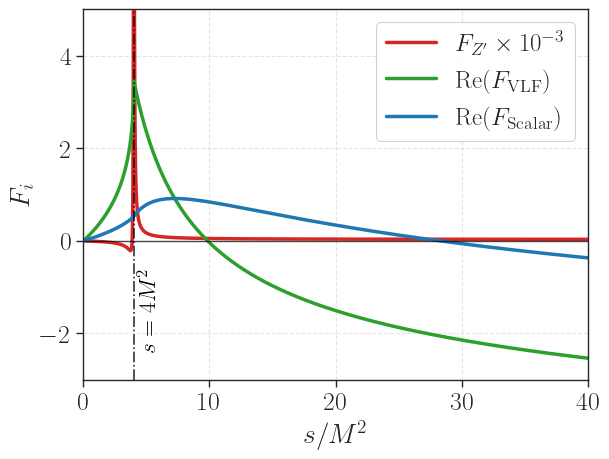

In [22]:
# Color palette
colors = plt.cm.tab10.colors

# --- Parameters ---
M_T = m = 1000.0
s_values = np.linspace(0.1 * m**2, 40 * m**2, 10000)

# --- Vectorized Complex Kinematics (Dimensionless x = s/M^2) ---
x = s_values / m**2

# Dimensionless Form Factors
F_scalar = scalarFF(s_values, m)
F_vlf = vlfFF(s_values, m)


# --- Visualization ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# Z' Resonance
M_Zp = 2.0 * m
F_zp = zprimeFF(s_values, M_Zp, G_Zp=M_Zp/100.0)
y_zp = 1e-3* F_zp
ax.plot(x, y_zp, color=colors[3], linewidth=2.5, alpha=1, label=r'$F_{Z^\prime} \times 10^{-3}$')

# VLF Curves (Real & Imaginary)
ax.plot(x, F_vlf.real, label=r'$\mathrm{Re}(F_{\rm VLF})$', color=colors[2], linestyle='-', linewidth=2.5)

# Scalar Curves (Real & Imaginary)
ax.plot(x, F_scalar.real, label=r'$\mathrm{Re}(F_{\rm Scalar})$', color=colors[0], linestyle='-', linewidth=2.5)

# Formatting
ax.axvline(4.0, color='black', linestyle='-.', alpha=0.8)
ax.axhline(0.0, color='black', linewidth=1, alpha=0.7)

# Vertical annotation in the negative y-region
ax.text(4.4, -1.5, r'$s = 4M^2$', fontsize=17, color='black', 
        rotation=90, verticalalignment='center')

# ax.set_title(r'Form Factor Shape') 
ax.set_xlabel(r'$s/M^2$',fontsize=20)
ax.set_ylabel(r'$F_i$',fontsize=20)

ax.set_ylim([-3, 5.0])
ax.set_xlim(0., 40.0)
ax.legend(loc='upper right', framealpha=0.9, ncol=1, fontsize=18) 
ax.tick_params(axis='both', which='major') 

ax.grid(True, alpha=0.5, linestyle='--')

minor_tick_locations = np.arange(0.0, 41.0, 1.0) 
# ax.xaxis.set_minor_locator(FixedLocator(minor_tick_locations))


plt.tight_layout()
plt.savefig('Form_Factor_real_spinFlip.png', dpi=300)
plt.show()

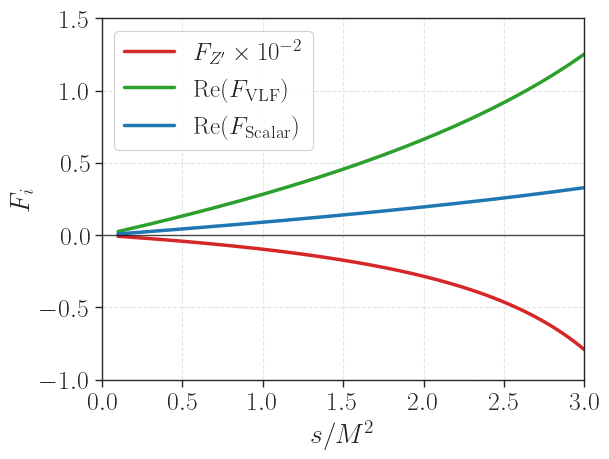

In [21]:
# Color palette
colors = plt.cm.tab10.colors

# --- Parameters ---
M_T = m = 1000.0
s_values = np.linspace(0.1 * m**2, 3* m**2, 1000)

# --- Vectorized Complex Kinematics (Dimensionless x = s/M^2) ---
x = s_values / m**2

# Dimensionless Form Factors
F_scalar = scalarFF(s_values, m)
F_vlf = vlfFF(s_values, m)


# --- Visualization ---
fig, ax = plt.subplots(figsize=(6.5, 5))

# Z' Resonance
M_Zp = 2.0 * m
F_zp = zprimeFF(s_values, M_Zp, G_Zp=M_Zp/100.0)
y_zp = 1e-2 * F_zp
ax.plot(x, y_zp, color=colors[3], linewidth=2.5, alpha=1, label=r'$F_{Z^\prime} \times 10^{-2}$')

# VLF Curves (Real & Imaginary)
ax.plot(x, F_vlf.real, label=r'$\mathrm{Re}(F_{\rm VLF})$', color=colors[2], linestyle='-', linewidth=2.5)

# Scalar Curves (Real & Imaginary)
ax.plot(x, F_scalar.real, label=r'$\mathrm{Re}(F_{\rm Scalar})$', color=colors[0], linestyle='-', linewidth=2.5)

# Formatting
ax.axvline(4.0, color='black', linestyle='-.', alpha=0.8)
ax.axhline(0.0, color='black', linewidth=1, alpha=0.7)


# ax.set_title(r'Form Factor Shape') 
ax.set_xlabel(r'$s/M^2$', fontsize=20)
ax.set_ylabel(r'$F_i$', fontsize=20)

ax.set_ylim([-1.0, 1.5])
ax.set_xlim([0, 3.0])
ax.legend(loc='upper left', framealpha=0.9, ncol=1, fontsize=18) 
ax.tick_params(axis='both', which='major') 

ax.grid(True, alpha=0.5, linestyle='--')

minor_tick_locations = np.arange(0.0, 41.0, 1.0) 
ax.xaxis.set_minor_locator(FixedLocator(minor_tick_locations))


plt.tight_layout()
plt.savefig('Form_Factor_lowE.png', dpi=300)
plt.show()